# BirdCLEF2026 - Data Ingestion and Preparation

This notebook handles audio loading, mel spectrogram generation, and data augmentation.

## Why This Matters

**Audio representation is critical** for model performance:

1. **Mel Spectrograms** convert audio to 2D images that CNNs can process
2. **Sampling rate** must match training (32kHz) to avoid frequency distortion
3. **Window size** determines time-frequency resolution trade-off
4. **Data augmentation** improves generalization to unseen field conditions

The key challenge: **field recordings have noise, overlapping species, and varying acoustic conditions**.
Our preprocessing must be robust to these variations.

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torchaudio
import librosa
import soundfile as sf
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set paths
DATA_DIR = Path("../input")
TRAIN_AUDIO_DIR = DATA_DIR / "train_audio"
TRAIN_SOUNDSCAPES_DIR = DATA_DIR / "train_soundscapes"
TEST_SOUNDSCAPES_DIR = DATA_DIR / "test_soundscapes"
OUTPUT_DIR = Path("../processed_data")
OUTPUT_DIR.mkdir(exist_ok=True)

# Load metadata
train_df = pd.read_csv(DATA_DIR / "train.csv")
taxonomy_df = pd.read_csv(DATA_DIR / "taxonomy.csv")
train_labels_df = pd.read_csv(DATA_DIR / "train_soundscapes_labels.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA GeForce GTX 1650


## 1. Audio Configuration

### Why These Parameters?

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| Sample Rate | 32 kHz | Matches test data, captures bird frequencies up to ~15kHz |
| Duration | 5 seconds | Matches prediction segment length, balances context vs. compute |
| N_FFT | 2048 | Good frequency resolution for bird calls |
| Hop Length | 512 | 50% overlap for smooth time resolution |
| N_Mels | 128 | Standard for bioacoustic tasks, balances frequency info |
| Fmin/Fmax | 50/15000 Hz | Captures most bird/animal vocalizations |

**Note**: Bird calls typically range from 1-10 kHz, but some species go higher. 32kHz captures up to 16kHz (Nyquist).

In [2]:
# Audio parameters
SAMPLE_RATE = 32000  # 32 kHz (matches test data)
DURATION = 5  # 5 seconds per clip
N_FFT = 2048
HOP_LENGTH = 512
N_MELS = 128
FMIN = 50
FMAX = 15000

# Derived values
EXPECTED_SAMPLES = SAMPLE_RATE * DURATION

print("Audio Configuration:")
print(f"  Sample Rate: {SAMPLE_RATE:,} Hz")
print(f"  Duration: {DURATION} seconds")
print(f"  Expected Samples: {EXPECTED_SAMPLES:,}")
print(f"  N_FFT: {N_FFT}")
print(f"  Hop Length: {HOP_LENGTH}")
print(f"  N_MELS: {N_MELS}")
print(f"  Frequency Range: {FMIN}-{FMAX} Hz")
print(f"\nSpectrogram shape: {N_MELS} x {EXPECTED_SAMPLES // HOP_LENGTH + 1}")

Audio Configuration:
  Sample Rate: 32,000 Hz
  Duration: 5 seconds
  Expected Samples: 160,000
  N_FFT: 2048
  Hop Length: 512
  N_MELS: 128
  Frequency Range: 50-15000 Hz

Spectrogram shape: 128 x 313


## 2. Audio Loading Functions

### Why These Design Choices?

1. **SoundFile over librosa**: Faster, handles ogg natively
2. **Stereo to mono**: Model expects 1D audio
3. **Resampling**: Ensures consistent sample rate across all files
4. **Padding/Truncation**: Fixed-length inputs required for batching

In [3]:
def load_audio(file_path, target_sr=SAMPLE_RATE):
    """Load audio file and resample if necessary.
    
    Args:
        file_path: Path to audio file
        target_sr: Target sample rate (default: 32000)
    
    Returns:
        waveform: Audio as numpy array
        sr: Actual sample rate
    """
    try:
        # Try using soundfile first
        waveform, sr = sf.read(file_path)
        
        # Handle stereo - convert to mono by averaging channels
        if len(waveform.shape) > 1:
            waveform = waveform.mean(axis=1)
        
        # Resample if needed to match test data sample rate
        if sr != target_sr:
            waveform = librosa.resample(waveform, orig_sr=sr, target_sr=target_sr)
        
        return waveform, target_sr
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None, None


def pad_or_truncate(waveform, target_samples=EXPECTED_SAMPLES):
    """Pad or truncate waveform to target length.
    
    This is necessary because:
    - Audio files have varying lengths
    - Neural networks need fixed-length inputs
    - For longer files: random crop (during training) or center crop (inference)
    - For shorter files: zero-pad at the end
    
    Args:
        waveform: Input audio
        target_samples: Target number of samples
    
    Returns:
        Fixed-length waveform
    """
    if len(waveform) > target_samples:
        # Random crop if longer (adds temporal variety during training)
        start = np.random.randint(0, len(waveform) - target_samples)
        waveform = waveform[start:start + target_samples]
    elif len(waveform) < target_samples:
        # Pad with zeros if shorter
        padding = target_samples - len(waveform)
        waveform = np.pad(waveform, (0, padding), mode='constant')
    return waveform

# Test loading
test_files = list(TRAIN_AUDIO_DIR.glob("**/*.ogg"))[:1]
if test_files:
    waveform, sr = load_audio(test_files[0])
    print(f"Loaded: {test_files[0].name}")
    print(f"Original shape: {len(waveform)}, Sample rate: {sr}")

Loaded: XC654360.ogg
Original shape: 3313580, Sample rate: 32000


## 3. Spectrogram Generation

### Why Mel Spectrograms?

Mel spectrograms are the **standard feature** for bioacoustic classification:

1. **Mel scale**: Mimics human auditory perception (better for biological sounds)
2. **Log scale**: Compresses dynamic range, makes quiet sounds visible
3. **2D representation**: Enables use of proven CNN architectures

**Normalization**: We normalize to [0,1] range which helps neural network training.

In [4]:
def get_mel_spectrogram(waveform, sr=SAMPLE_RATE):
    """Generate mel spectrogram from waveform.
    
    Args:
        waveform: Audio time series
        sr: Sample rate
    
    Returns:
        log_mel_spec: Log-scaled mel spectrogram
    """
    # Compute mel spectrogram
    mel_spec = librosa.feature.melspectrogram(
        y=waveform,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        fmin=FMIN,
        fmax=FMAX,
        power=2.0  # Power spectrogram (energy)
    )
    
    # Convert to log scale - this is crucial!
    # - Human perception is logarithmic
    # - Makes quiet sounds visible
    # - Standard in audio deep learning
    log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
    
    return log_mel_spec


def normalize_spectrogram(spec):
    """Normalize spectrogram to [0, 1] range.
    
    Why normalize?
    - Neural networks train better with normalized inputs
    - Different recordings have different overall energy
    - This makes the model focus on spectral patterns, not volume
    """
    spec = spec - spec.min()
    spec = spec / (spec.max() + 1e-8)  # +1e-8 to avoid division by zero
    return spec

# Test spectrogram generation
if test_files:
    waveform, sr = load_audio(test_files[0])
    waveform = pad_or_truncate(waveform)
    spec = get_mel_spectrogram(waveform)
    spec = normalize_spectrogram(spec)
    print(f"Spectrogram shape: {spec.shape}")
    print(f"Spectrogram range: [{spec.min():.2f}, {spec.max():.2f}]")

Spectrogram shape: (128, 313)
Spectrogram range: [0.00, 1.00]


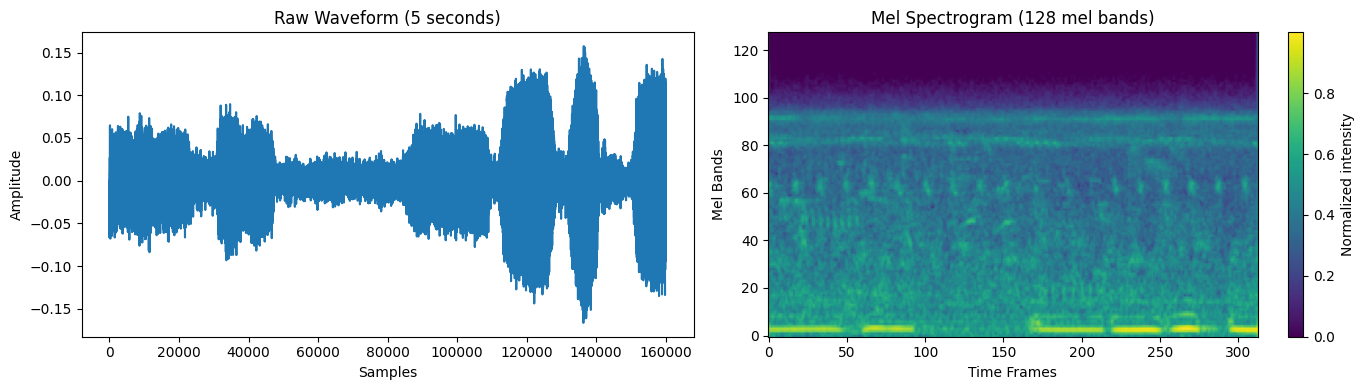


📊 Visualization shows how audio is converted to 2D representation


In [5]:
# Visualize sample spectrogram
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Raw waveform
axes[0].plot(waveform)
axes[0].set_title('Raw Waveform (5 seconds)')
axes[0].set_xlabel('Samples')
axes[0].set_ylabel('Amplitude')

# Mel spectrogram
im = axes[1].imshow(spec, aspect='auto', origin='lower', cmap='viridis')
axes[1].set_title('Mel Spectrogram (128 mel bands)')
axes[1].set_xlabel('Time Frames')
axes[1].set_ylabel('Mel Bands')
plt.colorbar(im, ax=axes[1], label='Normalized intensity')

plt.tight_layout()
plt.savefig('sample_spectrogram.png', dpi=100)
plt.show()

print("\n📊 Visualization shows how audio is converted to 2D representation")

## 4. Data Augmentation

### Why Augmentation?

**Critical for generalization** to field conditions:

| Augmentation | What it simulates | Why it matters |
|--------------|------------------|----------------|
| Gaussian Noise | Recording device noise, distant calls | Field recordings are noisy |
| Pitch Shift | Different bird sizes/ages, recording speed | Real variation |
| Time Stretch | Fast/slow singers | Natural tempo variation |
| Shift | Random start point | Different call positions |

**Note**: Augmentation is ONLY applied during training, not inference!

In [6]:
from audiomentations import (
    AddBackgroundNoise,
    AddGaussianNoise,
    Compose,
    PitchShift,
    TimeStretch,
    Shift
)

# Define augmentation pipeline
# These parameters are tuned for audio - not too aggressive
train_augmentations = Compose([
    AddGaussianNoise(min_amplitude=0.001, max_amplitude=0.015, p=0.3),
    # Gaussian noise: simulates recording/device noise
    # 0.3 probability, 0.1-1.5% amplitude range
    
    PitchShift(min_semitones=-2, max_semitones=2, p=0.3),
    # Pitch shift: simulates different bird sizes
    # ±2 semitones is a realistic range
    
    TimeStretch(min_rate=0.8, max_rate=1.2, p=0.3),
    # Time stretch: simulates fast/slow singers
    # 0.8-1.2x speed (not too extreme)
    
    Shift(min_shift=0, max_shift=0.2, shift_unit='fraction', p=0.3),
    # Shift: random temporal displacement
    # ±20% of clip length
])

def augment_waveform(waveform, sr=SAMPLE_RATE):
    """Apply augmentations to waveform.
    
    Called during training to increase effective dataset size
    and improve generalization to unseen conditions.
    """
    augmented = train_augmentations(waveform, sample_rate=sr)
    return augmented

# Test augmentation
if test_files:
    aug_waveform = augment_waveform(waveform.copy())
    print(f"Original waveform range: [{waveform.min():.3f}, {waveform.max():.3f}]")
    print(f"Augmented waveform range: [{aug_waveform.min():.3f}, {aug_waveform.max():.3f}]")
    print("✅ Augmentation applied")

Original waveform range: [-0.167, 0.158]
Augmented waveform range: [-0.167, 0.158]
✅ Augmentation applied


## 5. Dataset Classes

### Why Custom Dataset?

We need to handle:
1. **File-level labels** (train_audio)
2. **Segment-level labels** (train_soundscapes)
3. **Multi-label** (multiple species per segment)
4. **On-the-fly spectrogram generation** (can't fit all spectrograms in memory)

In [7]:
import torch.utils.data as data

class BirdDataset(data.Dataset):
    """Dataset for training audio files.
    
    Handles file-level labels from train_audio directory.
    Generates spectrograms on-the-fly to save memory.
    """
    
    def __init__(self, df, audio_dir, species_to_idx, 
                 augment=False, duration=DURATION, sample_rate=SAMPLE_RATE):
        self.df = df.reset_index(drop=True)
        self.audio_dir = audio_dir
        self.species_to_idx = species_to_idx
        self.augment = augment
        self.duration = duration
        self.sample_rate = sample_rate
        self.expected_samples = sample_rate * duration
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # Load audio
        file_path = self.audio_dir / row['filename']
        waveform, sr = load_audio(file_path, self.sample_rate)
        
        if waveform is None:
            # Return zeros if loading fails
            waveform = np.zeros(self.expected_samples)
        else:
            waveform = pad_or_truncate(waveform, self.expected_samples)
        
        # Augment if training
        if self.augment:
            waveform = augment_waveform(waveform, self.sample_rate)
        
        # Convert to tensor
        waveform = torch.FloatTensor(waveform)
        
        # Get mel spectrogram
        spec = get_mel_spectrogram(waveform.numpy(), self.sample_rate)
        spec = normalize_spectrogram(spec)
        
        # Convert to tensor (add channel dimension for CNN)
        # Shape: (1, 128, 313)
        spec = torch.FloatTensor(spec).unsqueeze(0)
        
        # Create label (single-species)
        label = torch.zeros(len(self.species_to_idx))
        species_idx = self.species_to_idx.get(row['primary_label'])
        if species_idx is not None:
            label[species_idx] = 1.0
        
        return spec, label

# Test dataset
species_columns = [col for col in sample_submission.columns if col not in ['row_id', 'filename', 'end_time']]
species_to_idx = {sp: i for i, sp in enumerate(species_columns)}

test_dataset = BirdDataset(
    train_df.head(10), 
    TRAIN_AUDIO_DIR, 
    species_to_idx,
    augment=False
)

spec, label = test_dataset[0]
print(f"Spectrogram shape: {spec.shape}")
print(f"Label shape: {label.shape}")
print(f"Label sum: {label.sum().item()}")

Spectrogram shape: torch.Size([1, 128, 313])
Label shape: torch.Size([234])
Label sum: 1.0


## 6. Prepare Train Soundscapes Dataset

### Why Separate Dataset for Soundscapes?

The train_soundscapes have **different characteristics**:
1. **Segment-level labels** - need to extract specific 5-second segments
2. **Multi-label** - multiple species can be present
3. **From same region as test** - critical for domain match

This is why we combine both datasets in training!

In [8]:
class SoundscapeDataset(data.Dataset):
    """Dataset for soundscape (field) recordings with segment labels.
    
    Handles segment-level labels from train_soundscapes.
    Supports multi-label (multiple species per segment).
    """
    
    def __init__(self, labels_df, audio_dir, species_to_idx,
                 augment=False, duration=DURATION, sample_rate=SAMPLE_RATE):
        self.labels_df = labels_df.reset_index(drop=True)
        self.audio_dir = audio_dir
        self.species_to_idx = species_to_idx
        self.augment = augment
        self.duration = duration
        self.sample_rate = sample_rate
        self.expected_samples = sample_rate * duration
        
    def __len__(self):
        return len(self.labels_df)
    
    def __getitem__(self, idx):
        row = self.labels_df.iloc[idx]
        
        # Parse time - format is HH:MM:SS
        start_time = self._parse_time(row['start'])
        
        # Load audio
        file_path = self.audio_dir / row['filename']
        waveform, sr = sf.read(file_path)
        
        # Handle stereo
        if len(waveform.shape) > 1:
            waveform = waveform.mean(axis=1)
        
        # Resample if needed
        if sr != self.sample_rate:
            waveform = librosa.resample(waveform, orig_sr=sr, target_sr=self.sample_rate)
        
        # Extract the specific 5-second segment
        start_sample = int(start_time * self.sample_rate)
        end_sample = start_sample + self.expected_samples
        
        if end_sample <= len(waveform):
            segment = waveform[start_sample:end_sample]
        else:
            segment = waveform[start_sample:]
            segment = pad_or_truncate(segment, self.expected_samples)
        
        # Augment if training
        if self.augment:
            segment = augment_waveform(segment, self.sample_rate)
        
        # Convert to tensor
        segment = torch.FloatTensor(segment)
        
        # Get mel spectrogram
        spec = get_mel_spectrogram(segment.numpy(), self.sample_rate)
        spec = normalize_spectrogram(spec)
        spec = torch.FloatTensor(spec).unsqueeze(0)
        
        # Create multi-label (multiple species can be present)
        label = torch.zeros(len(self.species_to_idx))
        species_list = row['primary_label'].split(';')
        for species in species_list:
            species_idx = self.species_to_idx.get(species.strip())
            if species_idx is not None:
                label[species_idx] = 1.0
        
        return spec, label
    
    def _parse_time(self, time_str):
        """Parse time string to seconds."""
        parts = time_str.split(':')
        return int(parts[0]) * 3600 + int(parts[1]) * 60 + int(parts[2])

# Test soundscape dataset
test_soundscape_ds = SoundscapeDataset(
    train_labels_df.head(10),
    TRAIN_SOUNDSCAPES_DIR,
    species_to_idx,
    augment=False
)

spec, label = test_soundscape_ds[0]
print(f"Soundscape spectrogram shape: {spec.shape}")
print(f"Label shape: {label.shape}")
print(f"Label sum (number of species): {label.sum().item()}")

Soundscape spectrogram shape: torch.Size([1, 128, 313])
Label shape: torch.Size([234])
Label sum (number of species): 5.0


## 7. Create Combined Dataset

### Why Combine Both Sources?

**Critical insight from EDA**:
- train_audio: Large quantity, but clean recordings, different domain
- train_soundscapes: Smaller, but from same region as test!

Combining both gives us:
1. **More training data** - larger dataset for learning
2. **Domain adaptation** - exposure to field recording characteristics
3. **Better generalization** - model sees both clean and noisy audio

In [9]:
class CombinedDataset(data.Dataset):
    """Combined dataset of train_audio and train_soundscapes.
    
    This combines:
    - train_audio: File-level labels, clean recordings
    - train_soundscapes: Segment-level labels, field recordings
    
    Why this matters:
    - More training samples = better model
    - Domain adaptation to field conditions
    - train_soundscapes has species only found there!
    """
    
    def __init__(self, train_df, labels_df, train_audio_dir, soundscapes_dir,
                 species_to_idx, augment=True):
        self.train_audio_dir = train_audio_dir
        self.soundscapes_dir = soundscapes_dir
        self.species_to_idx = species_to_idx
        self.augment = augment
        
        # Prepare train_audio data
        self.train_audio_df = train_df[['filename', 'primary_label']].copy()
        self.train_audio_df['source'] = 'audio'
        
        # Prepare soundscapes data
        self.soundscapes_df = labels_df[['filename', 'primary_label', 'start', 'end']].copy()
        self.soundscapes_df['source'] = 'soundscape'
        
        # Combine
        self.combined_df = pd.concat([
            self.train_audio_df.assign(index=range(len(self.train_audio_df))),
            self.soundscapes_df.assign(index=range(len(self.soundscapes_df)))
        ], ignore_index=True)
        
    def __len__(self):
        return len(self.combined_df)
    
    def __getitem__(self, idx):
        row = self.combined_df.iloc[idx]
        
        if row['source'] == 'audio':
            # Load from train_audio
            file_path = self.train_audio_dir / row['filename']
            waveform, sr = load_audio(file_path)
            if waveform is None:
                waveform = np.zeros(EXPECTED_SAMPLES)
            else:
                waveform = pad_or_truncate(waveform, EXPECTED_SAMPLES)
            
            # Create single-species label
            label = torch.zeros(len(self.species_to_idx))
            species_idx = self.species_to_idx.get(row['primary_label'])
            if species_idx is not None:
                label[species_idx] = 1.0
        else:
            # Load from soundscapes
            file_path = self.soundscapes_dir / row['filename']
            waveform, sr = sf.read(file_path)
            if len(waveform.shape) > 1:
                waveform = waveform.mean(axis=1)
            if sr != SAMPLE_RATE:
                waveform = librosa.resample(waveform, orig_sr=sr, target_sr=SAMPLE_RATE)
            
            # Extract segment
            start_time = self._parse_time(row['start'])
            start_sample = int(start_time * SAMPLE_RATE)
            segment = waveform[start_sample:start_sample + EXPECTED_SAMPLES]
            if len(segment) < EXPECTED_SAMPLES:
                segment = pad_or_truncate(segment, EXPECTED_SAMPLES)
            waveform = segment
            
            # Create multi-label
            label = torch.zeros(len(self.species_to_idx))
            for species in row['primary_label'].split(';'):
                species_idx = self.species_to_idx.get(species.strip())
                if species_idx is not None:
                    label[species_idx] = 1.0
        
        # Augment if training
        if self.augment:
            waveform = augment_waveform(waveform, SAMPLE_RATE)
        
        # Convert to tensor
        waveform = torch.FloatTensor(waveform)
        
        # Get mel spectrogram
        spec = get_mel_spectrogram(waveform.numpy(), SAMPLE_RATE)
        spec = normalize_spectrogram(spec)
        spec = torch.FloatTensor(spec).unsqueeze(0)
        
        return spec, label
    
    def _parse_time(self, time_str):
        parts = time_str.split(':')
        return int(parts[0]) * 3600 + int(parts[1]) * 60 + int(parts[2])

print("CombinedDataset class defined.")
print(f"\nThis will combine:")
print(f"  - {len(train_df):,} train_audio files")
print(f"  - {len(train_labels_df):,} train_soundscape segments")
print(f"  = {len(train_df) + len(train_labels_df):,} total training samples")

CombinedDataset class defined.

This will combine:
  - 35,549 train_audio files
  - 1,478 train_soundscape segments
  = 37,027 total training samples


## 8. Save Configuration

Save configuration for use in training notebook.

In [10]:
# Save configuration
import json

config = {
    "sample_rate": SAMPLE_RATE,
    "duration": DURATION,
    "n_fft": N_FFT,
    "hop_length": HOP_LENGTH,
    "n_mels": N_MELS,
    "fmin": FMIN,
    "fmax": FMAX,
    "num_species": len(species_to_idx),
    "species_list": species_columns
}

with open(OUTPUT_DIR / 'config.json', 'w') as f:
    json.dump(config, f, indent=2)

with open(OUTPUT_DIR / 'species_mapping.json', 'w') as f:
    json.dump(species_to_idx, f)

print("Configuration saved!")
print(f"\nConfig: {config}")

Configuration saved!

Config: {'sample_rate': 32000, 'duration': 5, 'n_fft': 2048, 'hop_length': 512, 'n_mels': 128, 'fmin': 50, 'fmax': 15000, 'num_species': 234, 'species_list': ['1161364', '116570', '1176823', '1491113', '1595929', '209233', '22930', '22956', '22961', '22967', '22973', '22983', '22985', '23150', '23154', '23158', '23176', '23724', '24279', '24285', '24287', '24321', '244024', '25073', '25092', '25214', '326272', '41970', '43435', '47144', '47158son01', '47158son02', '47158son03', '47158son04', '47158son05', '47158son06', '47158son07', '47158son08', '47158son09', '47158son10', '47158son11', '47158son12', '47158son13', '47158son14', '47158son15', '47158son16', '47158son17', '47158son18', '47158son19', '47158son20', '47158son21', '47158son22', '47158son23', '47158son24', '47158son25', '476521', '516975', '517063', '555123', '555145', '555146', '64898', '65377', '65380', '66971', '67107', '67252', '70711', '738183', '74113', '74580', '760266', 'ashgre1', 'astcra1', 'baf

## Summary

This notebook provides:

1. **Audio loading** - Handles various formats, resampling, mono conversion
2. **Mel spectrograms** - Standard bioacoustic features (128 bands, 5s windows)
3. **Data augmentation** - Noise, pitch shift, time stretch for generalization
4. **Dataset classes** - Handles both train_audio and train_soundscapes
5. **Combined dataset** - Merges both sources for domain adaptation

**Key insight**: We combine clean train_audio with field train_soundscapes to improve generalization to the test domain!